Task 0: Course project dataset exploration (2p)
This task is meant to help you start thinking about the course project. The choice you make here is not binding and you can change your topic and dataset later.

a) Find a potential dataset for the course project. This can be either an existing dataset (e.g. from Kaggle, a government open data portal, or another source) or an API that you plan to use for data collection. Provide the name and a link to the source. (0.5p)

b) Briefly describe the dataset in a markdown cell: what it contains, what variables it has, how many rows there are (or how many you plan to collect if using an API), and what you plan to do with it in the project. (0.5p)

c) Conduct exploratory data analysis on the dataset (or on a sample of the data you plan to collect). This includes computing summary statistics (e.g. using .describe()) and creating at least 2 visualizations of the data. (1p)

a)
Data set: F1 DRIVERS DATASET (1950 -2026)
https://www.kaggle.com/datasets/kushagrajain19/f1-drivers-dataset-1950-2026?resource=download

b) The data contains drivers' name and nationality, seasons compete, career totals, drivers' championships,and derived metrics.
Key variables:
Driver, Nationality, Seasons,Championships, Race Entries, Race Starts,Pole Positions, Race Wins, Podiums, Fastest Laps, Points, Active, Championship Years, Decade, Pole Rate, Start Rate, Win Rate, Podium Rate,Fastlap Rate, Points per entry, Years Active, Champion
Approximately 868 rows
My plan: I plan to analyze the National Dominance of F1 by comparing the toal championoships won by different nationality. 


Summary Statistic


,Driver,Nationality,Seasons,Championships,Race_Entries,Race_Starts,Pole_Positions,Race_Wins,Podiums,Fastest_Laps,...,Championship Years,Decade,Pole_Rate,Start_Rate,Win_Rate,Podium_Rate,FastLap_Rate,Points_Per_Entry,Years_Active,Champion
count,876,876,876,876.000000,876.000000,876.000000,876.000000,876.000000,876.000000,876.000000,...,35,876.000000,876.000000,876.000000,876.000000,876.000000,876.000000,876.000000,876.000000,876
unique,876,47,484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,Oscar Piastri,United Kingdom,[1952],NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,[2025],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
freq,1,166,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,841
mean,NaN,NaN,NaN,0.086758,31.296804,29.070776,1.315068,1.318493,3.969178,1.332192,...,NaN,1972.659817,0.011662,0.781646,0.011288,0.042004,0.012140,0.513014,3.730594,NaN
std,NaN,NaN,NaN,0.536024,57.147557,56.281635,6.557791,6.832204,15.197224,5.646575,...,NaN,20.616294,0.046314,0.323377,0.043718,0.106913,0.043896,1.342246,3.608944,NaN
min,NaN,NaN,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,NaN
25%,NaN,NaN,NaN,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,1960.000000,0.000000,0.666667,0.000000,0.000000,0.000000,0.000000,1.000000,NaN
50%,NaN,NaN,NaN,0.000000,7.000000,5.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,1970.000000,0.000000,0.965517,0.000000,0.000000,0.000000,0.000000,2.000000,NaN
75%,NaN,NaN,NaN,0.000000,30.000000,27.000000,0.000000,0.000000,0.250000,0.000000,...,NaN,1990.000000,0.000000,1.000000,0.000000,0.000973,0.000000,0.393478,5.000000,NaN


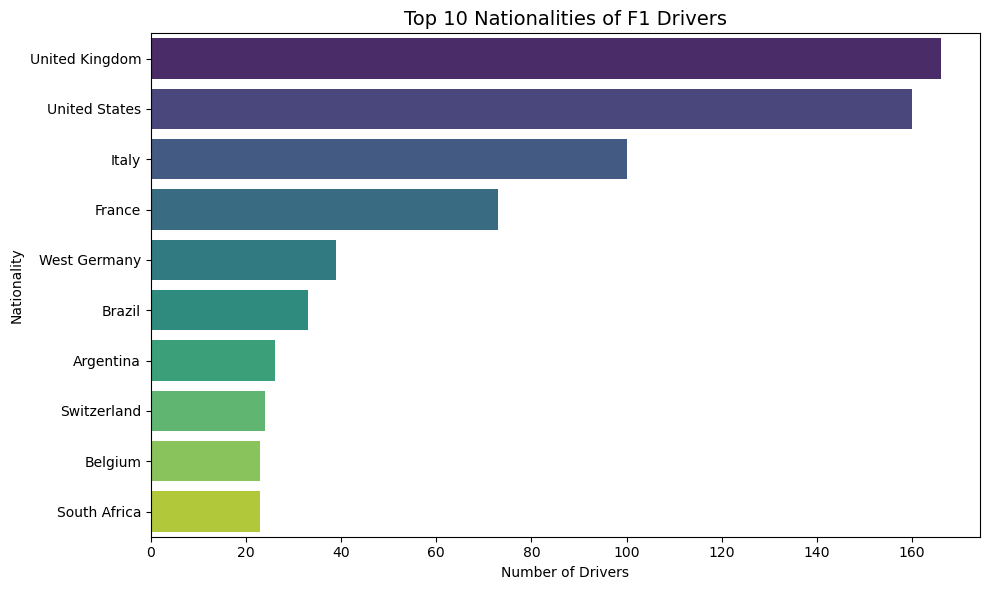

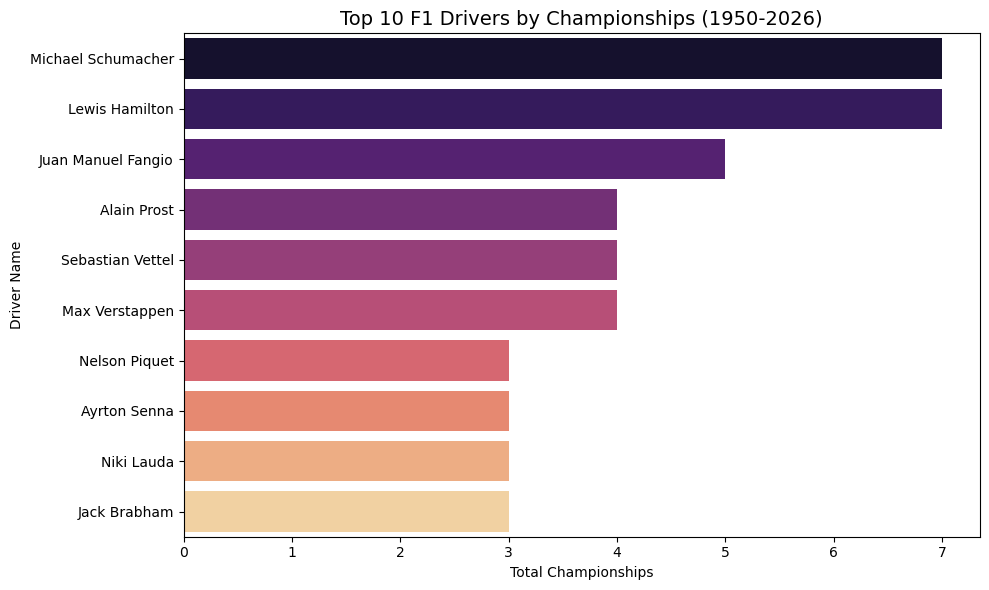

In [96]:
#c)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df_f1 = pd.read_csv('F1_driver.csv')
print("Summary Statistic")
display(df_f1.describe(include = 'all'))
#Visualization 1
plt.figure(figsize=(10, 6))
top_nations = df_f1['Nationality'].value_counts().head(10)
sns.barplot(x=top_nations.values, y=top_nations.index,hue =top_nations.index,  palette='viridis', legend = False)
plt.title('Top 10 Nationalities of F1 Drivers', fontsize=14)
plt.xlabel('Number of Drivers')
plt.ylabel('Nationality')
plt.tight_layout()
plt.show()

#Visualization 2:
plt.figure(figsize=(10, 6))
top_champs = df_f1.sort_values(by='Championships', ascending=False).head(10)
sns.barplot(data=top_champs, x='Championships', y='Driver', hue = 'Driver', palette='magma',legend = False)
plt.title('Top 10 F1 Drivers by Championships (1950-2026)', fontsize=14)
plt.xlabel('Total Championships')
plt.ylabel('Driver Name')
plt.tight_layout()
plt.show()


Task 1: Setting up an API key and .env file (1p)
Set up an account and get a free-tier API key at https://marketstack.com/ (no bank details required).

Store the API key in a .env file and load it in your notebook using python-dotenv. Print out only the first 5 characters of the key (e.g. print(api_key[:5] + "...")) to confirm it loaded correctly. Make sure the output is visible in the submitted notebook.

Important: Do not include the .env file in your GitHub repository. Add .env to your .gitignore. The API key must not be fully visible anywhere in the notebook or repository.

In [3]:
with open('.gitignore', 'w') as f:
    f.write('.env')
print("Created file .gitignore to hide file .env!")

Created file .gitignore to hide file .env!


In [5]:
import os
from dotenv import load_dotenv

# Load lại dữ liệu
load_dotenv()
api_key = os.getenv("MARKETSTACK_API_KEY")

print(api_key[:5] + "...")


8d7a1...


Task 2: Retrieving data from MarketStack (1p)
Use the MarketStack API to investigate how the FAANG stocks performed in March 2026. The FAANG companies and their ticker symbols are: Facebook/Meta (META), Apple (AAPL), Amazon (AMZN), Netflix (NFLX), and Google/Alphabet (GOOG).

a) Retrieve End-of-Day (eod) data for these five stocks for March 2026. Note: Each ticker in a request counts as a separate API call against your monthly limit, so plan your requests accordingly. Retrieving the data once should take only 5% of the monthly free API calls.



In [6]:
import requests
params = {
    'access_key': api_key,
    'symbols': 'META,AAPL,AMZN,NFLX,GOOG',
    'date_from': '2026-03-01',
    'date_to': '2026-03-31',
    'limit': 1000 
}
base_url = 'https://api.marketstack.com/v1/eod'
response = requests.get(base_url, params = params)

#Check if the data is imported succesfully or not
if response.status_code ==200:
    stock_data_json = response.json()
    print("succesfully retrievede data for March 2026.")
else:
    print(f"Error: {response.status_code}.")
    


succesfully retrievede data for March 2026.


b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows

In [5]:
import pandas as pd
if 'stock_data_json' in locals() and 'data' in stock_data_json:
    df = pd.DataFrame (stock_data_json['data'])
    df['date'] = pd.to_datetime(df['date'])
    print("First 5 rows of stock data:")
    display(df.head())


First 5 rows of stock data:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31 00:00:00+00:00
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31 00:00:00+00:00
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31 00:00:00+00:00
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31 00:00:00+00:00
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31 00:00:00+00:00


c) Compute summary statistics for the closing prices grouped by stock. Also calculate the return percentage for each stock over the month (i.e. the percentage change from the first to the last trading day). Print out the computed numbers or a DataFrame that contains the numbers, and report which stock performed best and which worst in March 2026.



In [28]:
#1) summary statistics for the closing prices grouped by stock
summary_stats = df.groupby('symbol')['close'].describe()
print("\nSummary statistics for closing prices:")
display(summary_stats)
#2)Calculate return percentage
returns = []
for ticker in ['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG']:
    ticker_df = df[df['symbol'] == ticker].sort_values('date')
    if not ticker_df.empty:
        first_price = ticker_df.iloc[0]['close']
        last_price = ticker_df.iloc[-1]['close']
        return_pct = ((last_price - first_price) / first_price) * 100
        returns.append({'Symbol': ticker, 'Return_%': return_pct})

returns_df = pd.DataFrame(returns)
print("\nMonthly return percentage (03/2026:")
display(returns_df)

#3) Report the best and worst
best_stock = returns_df.loc[returns_df['Return_%'].idxmax()]  # Fixed missing closing quote
worst_stock = returns_df.loc[returns_df['Return_%'].idxmin()]  # Fixed missing closing quote

print(f"\nBest Performance: {best_stock['Symbol']} ({best_stock['Return_%']:.2f}%)")
print(f"Worst Performance: {worst_stock['Symbol']} ({worst_stock['Return_%']:.2f}%)")


Summary statistics for closing prices:


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17



Monthly return percentage (03/2026:


,Symbol,Return_%
0,META,-12.459453
1,AAPL,-4.128891
2,AMZN,-0.057584
3,NFLX,-0.968174
4,GOOG,-6.365061



Best Performance: AMZN (-0.06%)
Worst Performance: META (-12.46%)


Task 3: Visualizing stock data (1p)
Using the data from Task 2, create the following visualizations with seaborn:

a) A line chart showing the closing price of each stock over time during March 2026. The x-axis should be the date and the y-axis the closing price. Use distinct colors for each stock and include a legend.

b) A bar plot showing the overall return percentage for each stock in March 2026.

c) A heatmap showing the daily trading volume for each stock (stocks on the y axis, dates on the x axis).

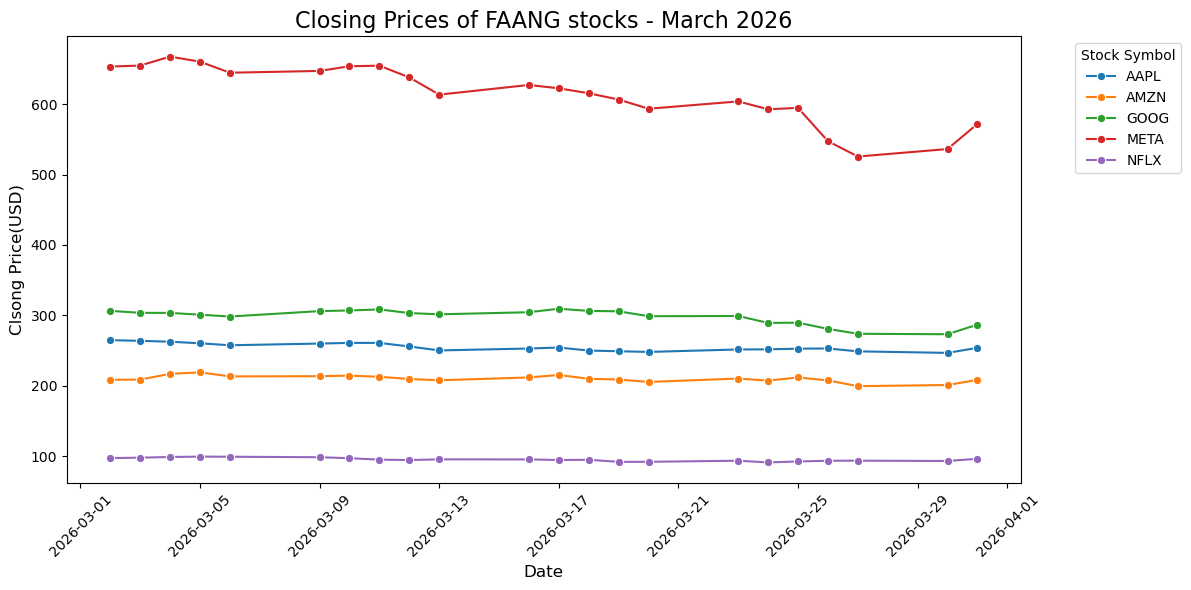

In [31]:
#a) A line chart
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (12,6))
line_plot = sns.lineplot(data=df, x = 'date', y = 'close', hue = 'symbol', marker = 'o')
plt.title('Closing Prices of FAANG stocks - March 2026', fontsize = 16)
plt.xlabel('Date', fontsize = 12)
plt.ylabel('Clsong Price(USD)', fontsize = 12)

plt.legend(title = 'Stock Symbol', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


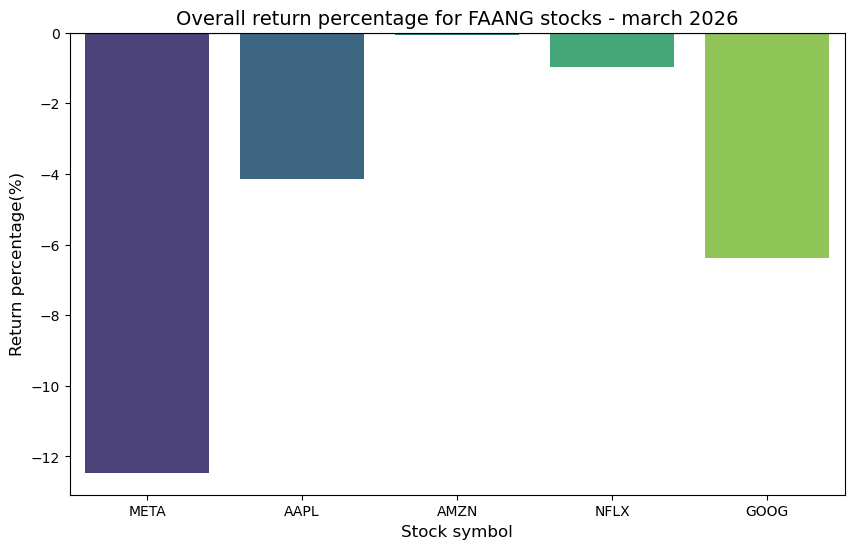

In [34]:
#b) A bar plot showing th overall return percentage
plt.figure(figsize = (10,6))
sns.barplot(data= returns_df, x = 'Symbol', y = 'Return_%', palette = 'viridis', hue = 'Symbol', legend = False)
plt.title('Overall return percentage for FAANG stocks - march 2026', fontsize = 14)
plt.xlabel('Stock symbol', fontsize =12)
plt.ylabel('Return percentage(%)', fontsize = 12)
plt.axhline(0, color = 'black', linewidth = 0.8)

plt.show()

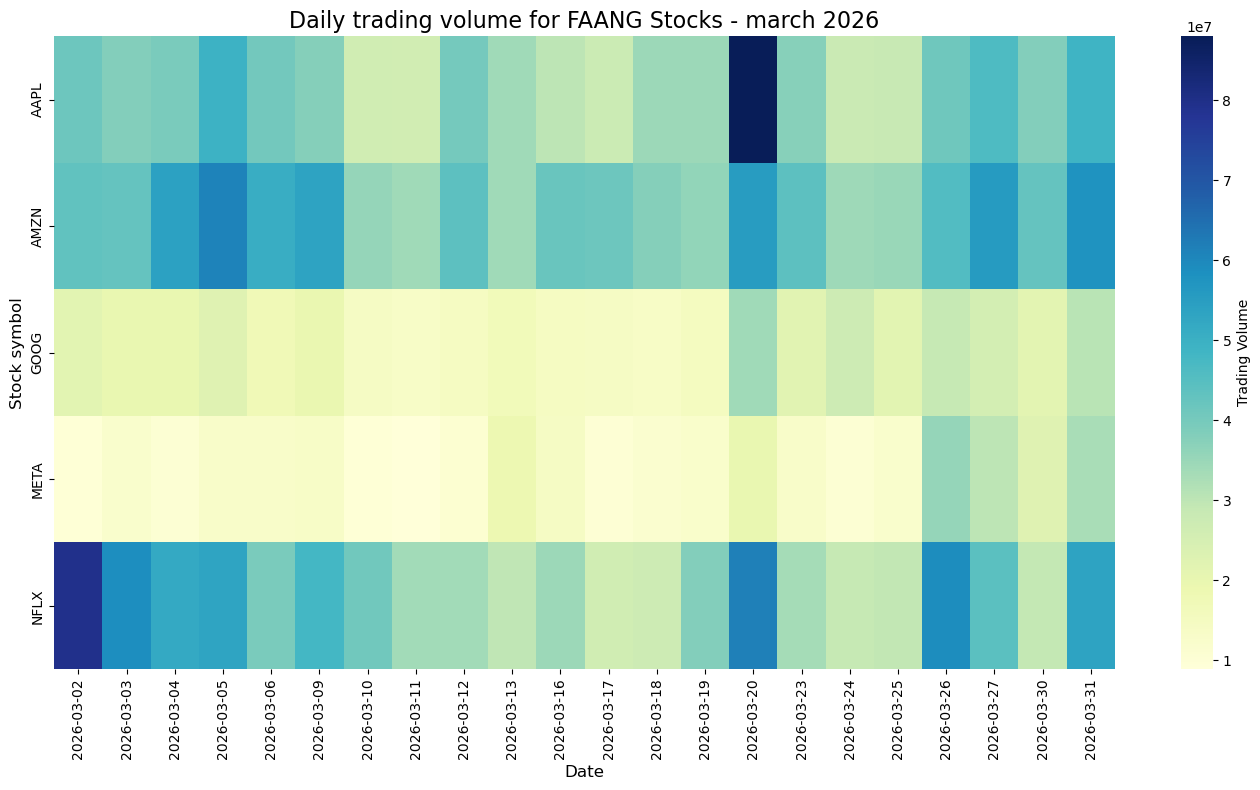

In [38]:
#3c) A heatmap showing the daily trading volume
plt.figure(figsize = (14, 8))
volume_pivot = df.pivot(index = 'symbol', columns = 'date', values = 'volume')
volume_pivot.columns = [d.strftime('%Y-%m-%d') for d in volume_pivot.columns]
sns.heatmap(data=volume_pivot, annot = False, cmap = 'YlGnBu', cbar_kws ={'label': 'Trading Volume'})  # Fixed colormap name from 'YLGnBu' to 'YlGnBu'
plt.title('Daily trading volume for FAANG Stocks - march 2026', fontsize = 16)
plt.xlabel('Date', fontsize = 12)
plt.ylabel('Stock symbol', fontsize =12)

plt.tight_layout()
plt.show()

Task 4: Exporting and importing data (1p)
a) Export the JSON data retrieved in Task 2a as a JSON file stockdata.json into a subfolder called exports.

b) Export the DataFrame from Task 2b as a CSV file stockdata.csv into the same exports subfolder.

c) Load back the exported data from both a) and b). Print the first five rows of each and verify that the data looks identical to what it was in Task 2.

In [39]:
#4a) 
import json
import os

folder_name = 'exports'
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"Created folder: {folder_name}")
json_file_path = os.path.join(folder_name, 'stockdata.json')
with open(json_file_path, 'w') as f:
    json.dump(stock_data_json, f, indent = 4)

print(f"Succcesfully exported JSON data to :{json_file_path}")

Created folder: exports
Succcesfully exported JSON data to :exports/stockdata.json


In [40]:
#4b) Export the dataframe from task 2b as a CSV file stockdata.csv
csv_file_path = os.path.join('exports', 'stockdata.csv')
df.to_csv(csv_file_path, index = False)

print(f"Succefully exported CSV data to: {csv_file_path}")



Succefully exported CSV data to: exports/stockdata.csv


In [44]:
#4c)Load back the exported data
import pandas as pd
import json
with open('exports/stockdata.json','r') as f:
    loaded_json_data = json.load(f)
df_from_json = pd.DataFrame(loaded_json_data['data'])
df_from_csv = pd.read_csv('exports/stockdata.csv')
print("First 5 rows from file JSON")
display(df_from_json.head())
print("\n 5 first row from CSV file")
display(df_from_csv.head())
if len(df_from_json) == len(df_from_csv):
    print("\n Verify succesfully: The data are identical")



First 5 rows from file JSON


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31T00:00:00+0000
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31T00:00:00+0000
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31T00:00:00+0000
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31T00:00:00+0000



 5 first row from CSV file


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31 00:00:00+00:00
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31 00:00:00+00:00
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31 00:00:00+00:00
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31 00:00:00+00:00
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31 00:00:00+00:00



 Verify succesfully: The data are identical


Task 5: Querying the Northwind database (1p)
Download an SQLite version of Microsoft's Northwind database (from https://github.com/jpwhite3/northwind-SQLite3, press the Download Here button). Connect to the database using sqlite3.

a) Connect to the database and list all tables it contains (print the table names).

b) Write a SQL query that retrieves all products with a unit price above 30, showing ProductName, UnitPrice, and UnitsInStock. Load the result into a DataFrame and print it.

c) Write a SQL query that joins the Orders, Customers, and Order Details tables to show CompanyName, OrderID, OrderDate, ShipCountry, and the line total (UnitPrice * Quantity) for all orders shipped to Germany. Load the result into a DataFrame and print it. Note, order details needs to be written as 'Order Details' within the quotation marks in the query since it consists of two words as the table name.

In [47]:
#5a) Connect to the database and list all tables it contains
import sqlite3
import pandas as pd
conn = sqlite3.connect('northwind.db')
print("Succesfully connect")

print("Task 5a) List of tables")
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type = 'table';")
tables = cursor.fetchall()

for table in tables:
    print(table[0])

Succesfully connect
Task 5a) List of tables
Categories
sqlite_sequence
CustomerCustomerDemo
CustomerDemographics
Customers
Employees
EmployeeTerritories
Order Details
Orders
Products
Regions
Shippers
Suppliers
Territories


In [49]:
#5b) write a sql query
query_b = """
 SELECT ProductName,
         UnitPrice,
         UnitsInStock
 FROM Products
 Where UnitPrice > 30
 ORDER BY UnitPrice DESC;
"""
df_b = pd.read_sql_query(query_b, conn)
print(df_b)
         



                   ProductName  UnitPrice  UnitsInStock
0                Côte de Blaye     263.50            17
1      Thüringer Rostbratwurst     123.79             0
2              Mishi Kobe Niku      97.00            29
3       Sir Rodney's Marmalade      81.00            40
4             Carnarvon Tigers      62.50            42
5         Raclette Courdavault      55.00            79
6        Manjimup Dried Apples      53.00            20
7               Tarte au sucre      49.30            17
8                  Ipoh Coffee      46.00            17
9            Rössle Sauerkraut      45.60            26
10          Schoggi Schokolade      43.90            49
11                Vegie-spread      43.90            24
12  Northwoods Cranberry Sauce      40.00             6
13                Alice Mutton      39.00             0
14   Queso Manchego La Pastora      38.00            86
15      Gnocchi di nonna Alice      38.00            21
16            Gudbrandsdalsost      36.00       

In [52]:
#5c) 
query_c = """
 SELECT c.CompanyName,
        o.OrderID,
        o.OrderDate,
        o.ShipCountry,
        od.UnitPrice * od.Quantity AS LineTotal
 FROM Orders o
 JOIN Customers c ON o.CustomerID = c.CustomerID
 JOIN 'Order Details' od ON o.OrderID = od.OrderID
 WHERE o.ShipCountry = 'Germany'
 ORDER BY o.OrderID;
"""

df_c = pd.read_sql_query(query_c, conn)
print(df_c)

conn.close()

              CompanyName  OrderID            OrderDate ShipCountry  LineTotal
0      Toms Spezialitäten    10249           2016-07-05     Germany      167.4
1      Toms Spezialitäten    10249           2016-07-05     Germany     1696.0
2      Ottilies Käseladen    10260           2016-07-19     Germany      123.2
3      Ottilies Käseladen    10260           2016-07-19     Germany      780.0
4      Ottilies Käseladen    10260           2016-07-19     Germany      591.0
...                   ...      ...                  ...         ...        ...
80668    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany      864.0
80669    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany      735.0
80670    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany       75.0
80671    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany      500.0
80672    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany       77.5

[80673 rows x 5 columns]


Task 6: Visualizing Northwind data (1p)
Using the query results from Task 5, create the following visualizations:

a) Using the result from Task 5c, create a bar plot showing the number of orders per customer (for the top 10 customers who shipped to Germany).

b) Using the result from Task 5c, compute the total sales per order date and create a density plot (KDE plot) of daily total sales for orders shipped to Germany. The density plot shows the distribution of sales volumes, i.e., makes it easy to see the typical size of daily sales volumes.

c) Write a new SQL query that joins OrderDetails, Products, and Categories using inner joins to compute the total revenue (UnitPrice * Quantity) per product category. Load the result into a DataFrame and create a bar plot showing total revenue by category.

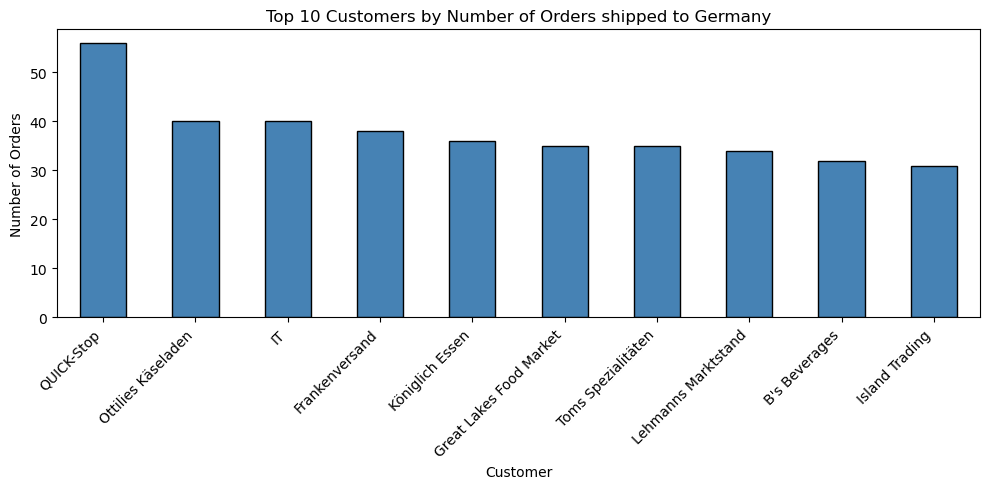

In [53]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('northwind.db')
query_c = """
 SELECT c.CompanyName,
        o.OrderID,
        o.OrderDate,
        o.ShipCountry,
        od.UnitPrice * od.Quantity AS LineTotal
 FROM Orders o
 JOIN Customers c ON o.CustomerID = c.CustomerID
 JOIN 'Order Details' od ON o.OrderID = od.OrderID
 WHERE o.ShipCountry = 'Germany'
 ORDER BY o.OrderID;
"""

df_c = pd.read_sql_query(query_c, conn)

#6a) Create a bar plot
orders_per_customer= (
    df_c.groupby("CompanyName")["OrderID"]
    .nunique()
    .sort_values(ascending = False)
    .head(10)
)
plt.figure(figsize = (10, 5))
orders_per_customer.plot(kind = "bar", color = "steelblue", edgecolor = "black")
plt.title("Top 10 Customers by Number of Orders shipped to Germany")
plt.xlabel("Customer")
plt.ylabel("Number of Orders")
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.savefig("6a_orders_per_customer.png", dpi = 150)
plt.show()

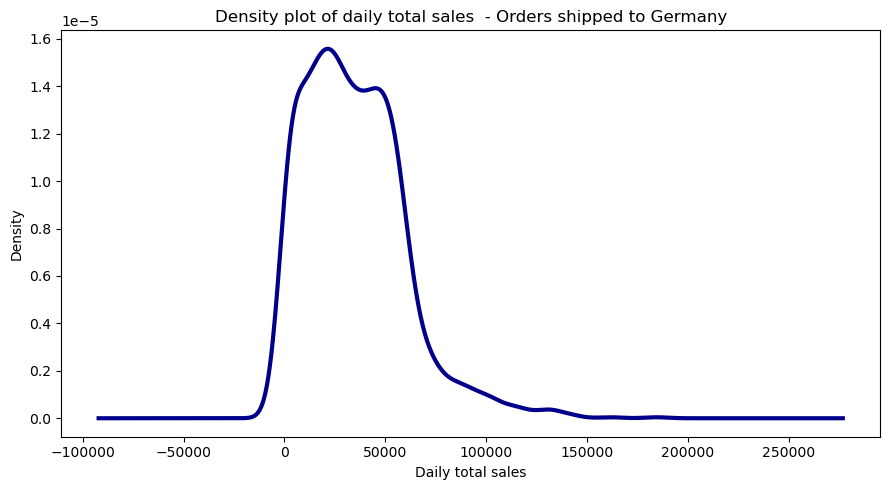

In [56]:
#5b)
#Convert Orderdate to datetime and sum LInetotal per day
# Use format='mixed' to handle the datetime format automatically
df_c["OrderDate"] = pd.to_datetime(df_c["OrderDate"], format='mixed')

# Extract just the date part (without time) for daily grouping
df_c["OrderDate"] = df_c["OrderDate"].dt.date

daily_sales = df_c.groupby("OrderDate")["LineTotal"].sum()

plt.figure(figsize = (9,5))
daily_sales.plot(kind = "kde", color = "darkblue", linewidth = 3)
plt.title("Density plot of daily total sales  - Orders shipped to Germany")
plt.xlabel("Daily total sales")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("6b_kde_daily_sales.png", dpi = 150)
plt.show()

     CategoryName  TotalRevenue
0       Beverages   92181842.95
1     Confections   66347544.94
2    Meat/Poultry   64896314.41
3  Dairy Products   58034940.00
4      Condiments   55802774.45
5         Seafood   49931965.52
6         Produce   32706403.90
7  Grains/Cereals   28573512.55


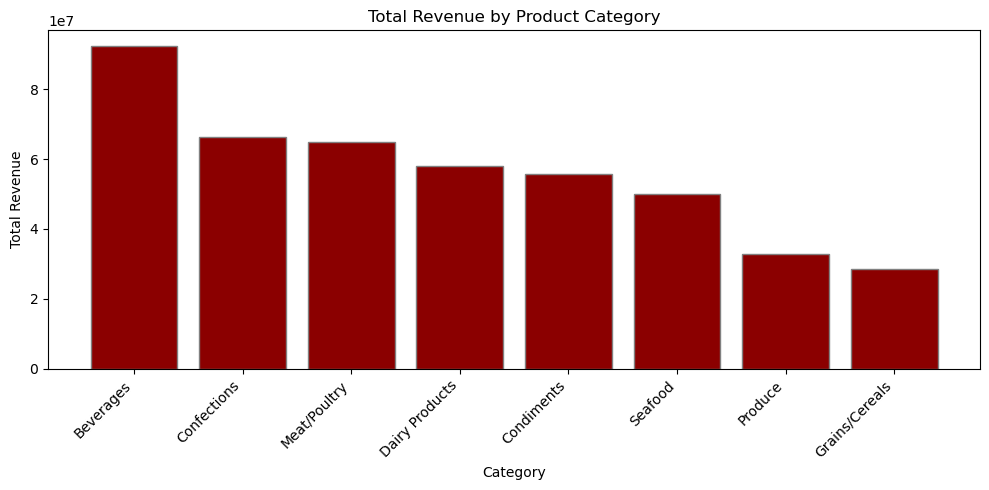

In [61]:
#6c)
query_6c = """
 SELECT cat.CategoryName,
        SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
 FROM 'Order Details' od
 JOIN Products p ON od.ProductID = p.ProductID
 JOIN Categories cat ON p.CategoryID = cat.CategoryID
 GROUP BY cat.CategoryName
 ORDER BY TotalRevenue DESC;
"""
df_6c = pd.read_sql_query(query_6c, conn)
print(df_6c)

plt.figure(figsize = (10,5))
plt.bar(df_6c["CategoryName"], df_6c["TotalRevenue"], color = "darkred", edgecolor = "grey")
plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.savefig("6c_revenue_by_category.png", dpi = 150)
plt.show()
conn.close()

Task 7: Comparing Python to SQL (1p)
a) Write a SQL query that retrieves the full Products table and the full Categories table into separate DataFrames. Print the first 5 rows of each.

b) Using pandas, perform an inner join on the two DataFrames from 7a on CategoryID.

c) Replicate with Python the SQL code of Task 6c, retrieving first the tables fully using SQL and joining them with pandas. Using %%time or time.time(), compare the execution speed of performing the join fully with SQL (as in 6c) versus performing it in Python with pandas after retrieving via SQL the tables only (similar to what was done in Task 7a-b). Print both execution times and briefly comment on which was faster.

In [64]:
import sqlite3
import pandas as pd
import time
conn = sqlite3.connect('northwind.db')
#7a) 
df_products = pd.read_sql_query("SELECT * FROM Products;", conn)
df_categories = pd.read_sql_query ("SELECT * FROM Categories;", conn)

print("Products (first 5 rows):")
print(df_products.head())
print("\nCategories(first 5 rows):")
print(df_categories.head())


Products (first 5 rows):
   ProductID                   ProductName  SupplierID  CategoryID  \
0          1                          Chai           1           1   
1          2                         Chang           1           1   
2          3                 Aniseed Syrup           1           2   
3          4  Chef Anton's Cajun Seasoning           2           2   
4          5        Chef Anton's Gumbo Mix           2           2   

       QuantityPerUnit  UnitPrice  UnitsInStock  UnitsOnOrder  ReorderLevel  \
0   10 boxes x 20 bags      18.00            39             0            10   
1   24 - 12 oz bottles      19.00            17            40            25   
2  12 - 550 ml bottles      10.00            13            70            25   
3       48 - 6 oz jars      22.00            53             0             0   
4             36 boxes      21.35             0             0             0   

  Discontinued  
0            0  
1            0  
2            0  
3          

In [65]:
#7b)
df_joined = df_products.merge(df_categories, on = "CategoryID", how = "inner")
print("\nJoined DataFrame(first 5 rows):")
print(df_joined.head())


Joined DataFrame(first 5 rows):
   ProductID                   ProductName  SupplierID  CategoryID  \
0          1                          Chai           1           1   
1          2                         Chang           1           1   
2          3                 Aniseed Syrup           1           2   
3          4  Chef Anton's Cajun Seasoning           2           2   
4          5        Chef Anton's Gumbo Mix           2           2   

       QuantityPerUnit  UnitPrice  UnitsInStock  UnitsOnOrder  ReorderLevel  \
0   10 boxes x 20 bags      18.00            39             0            10   
1   24 - 12 oz bottles      19.00            17            40            25   
2  12 - 550 ml bottles      10.00            13            70            25   
3       48 - 6 oz jars      22.00            53             0             0   
4             36 boxes      21.35             0             0             0   

  Discontinued CategoryName  \
0            0    Beverages   
1        

In [72]:
#7c)
# Method 1: FULL SQL
start_sql = time.time()
query_sql = """
 SELECT cat.CategoryName,
        SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
        FROM 'Order Details' od
        JOIN Products p ON od.ProductID = p.ProductID
        JOIN Categories cat ON p.CategoryID = cat.CategoryID
        GROUP BY cat.CategoryName
        ORDER BY TotalRevenue DESC;
"""
df_sql_result = pd.read_sql_query(query_sql, conn)

end_sql = time.time()
sql_time = end_sql - start_sql

# Method 2: With PANDAS
start_pandas = time.time()
df_order_details = pd.read_sql_query("SELECT * FROM 'Order Details';", conn)
df_products2 = pd.read_sql_query("SELECT * FROM Products;", conn)
df_categories2 = pd.read_sql_query("SELECT * FROM Categories;", conn)

df_merged = df_order_details.merge(df_products2, on = "ProductID", how = "inner")
df_merged = df_merged.merge(df_categories2, on = "CategoryID", how="inner")  # Fixed missing equals sign
df_merged["Revenue"] = df_merged["UnitPrice_x"] * df_merged["Quantity"]  # Fixed curly braces to square brackets
df_pandas_result = (
    df_merged.groupby("CategoryName")["Revenue"]
    .sum()
    .reset_index()
    .rename(columns = {"Revenue": "TotalRevenue"})  # Fixed semicolon to colon
    .sort_values("TotalRevenue", ascending = False)  # Fixed typo in "ascending"
)
end_pandas = time.time()
pandas_time = end_pandas - start_pandas

print(f"\nSQL execution time: {sql_time:.6f} seconds")  # Fixed f-string formatting
print(f"Pandas execution time: {pandas_time:.6f} seconds")

faster = "SQL" if sql_time < pandas_time else "Pandas"
print(f"\n→ {faster} was faster.")


SQL execution time: 0.375840 seconds
Pandas execution time: 0.554961 seconds

→ SQL was faster.


SQL is usually faster: the database does joins and agregations itself and sends only the summarized result back. Using pandas normally pulls three full raw tables into Python and does the work in memory, whihc adds overhead-especially as the tables get larger

Task 8: Wide and long format (1p)
You are given two datasets. The first is in wide format:

wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})
The second is in long format:

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})
a) Convert wide_data from wide to long format using pd.melt(). Print the DataFrame before and after conversion.

b) Convert long_data from long to wide format using .pivot(). Print the DataFrame before and after conversion.

c) Convert both transformed datasets back to their original format. Print the datasets before and after to confirm they match the originals.

In [90]:
import pandas as pd
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})
long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})



In [81]:
#8a)
print("a) Wide to Long")
print("Before (wide_data):")
print(wide_data)

# First, check the actual column names in the DataFrame
print("\nColumn names:", wide_data.columns.tolist())

# Use the correct column name as the id_vars
# After checking the column names in the output, replace 'Store' with the actual first column name
wide_to_long = pd.melt(
    wide_data,
    id_vars=wide_data.columns[0],  # Use the first column dynamically, whatever its name is
    var_name="quarter",
    value_name="sales"
)

print("\nAfter (melted):")
print(wide_to_long)


a) Wide to Long
Before (wide_data):
  month product  units_sold
0   Jan  Laptop          45
1   Jan   Phone         120
2   Feb  Laptop          50
3   Feb   Phone         110
4   Mar  Laptop          55
5   Mar   Phone         130

Column names: ['month', 'product', 'units_sold']

After (melted):
   month     quarter   sales
0    Jan     product  Laptop
1    Jan     product   Phone
2    Feb     product  Laptop
3    Feb     product   Phone
4    Mar     product  Laptop
5    Mar     product   Phone
6    Jan  units_sold      45
7    Jan  units_sold     120
8    Feb  units_sold      50
9    Feb  units_sold     110
10   Mar  units_sold      55
11   Mar  units_sold     130


In [82]:
#8b)
print("b) Long to Wide")
print("Before (long_data):")
print(long_data)

long_to_wide = long_data.pivot(
    index = "month",
    columns = "product",
    values = "units_sold"
).reset_index()
long_to_wide.columns.name = None

print("\nAfter (pivoted):")
print(long_to_wide)



nnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnn
b) Long to Wide
Before (long_data):
  month product  units_sold
0   Jan  Laptop          45
1   Jan   Phone         120
2   Feb  Laptop          50
3   Feb   Phone         110
4   Mar  Laptop          55
5   Mar   Phone         130

After (pivoted):
  month  Laptop  Phone
0   Feb      50    110
1   Jan      45    120
2   Mar      55    130


In [91]:
#8c)
print("c) CONVERTING BACK TO ORIGINALS")

#Long to wide
print("\nReversing a): Long back to Wide")

# Re-create wide_to_long 
wide_to_long = pd.melt(
    wide_data,
    id_vars="store",
    var_name="quarter",
    value_name="sales"
)

print("Before:")
print(wide_to_long)

restored_wide = wide_to_long.pivot(
    index="store",
    columns="quarter",
    values="sales"
).reset_index()
restored_wide.columns.name = None

print("\nAfter (restored wide_data):")
print(restored_wide)

c) CONVERTING BACK TO ORIGINALS

Reversing a): Long back to Wide
Before:
       store   quarter  sales
0   Helsinki  Q1_sales  12000
1    Tampere  Q1_sales   8500
2      Turku  Q1_sales   9200
3   Helsinki  Q2_sales  13500
4    Tampere  Q2_sales   9100
5      Turku  Q2_sales   9800
6   Helsinki  Q3_sales  11800
7    Tampere  Q3_sales   8800
8      Turku  Q3_sales  10100
9   Helsinki  Q4_sales  15000
10   Tampere  Q4_sales  10200
11     Turku  Q4_sales  11500

After (restored wide_data):
      store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500


STATEMENT OF AI
I utilized Gemini (Google) as a coding assistant to complete this assignment. The AI helped me with fetching data from the Marketstack API, constructing SQL JOIN queries, and troubleshooting environment path issues on my Mac. While the AI provided initial code structures and debugging tips, I have carefully reviewed, tested, and modified the code to ensure I fully understand its logic and that it correctly meets all assignment requirements.
